# Yoga Pose Classifier
**Pipeline:** MediaPipe Pose (33 joints) → landmark extraction → normalization → TensorFlow classifier  
**Dataset:** `yoga_poses/` with `train/` and `test/` folders, each containing one subfolder per pose class.

## 1. Install dependencies

In [ ]:
!pip install mediapipe --quiet
!pip install tensorflow scikit-learn matplotlib seaborn --quiet

## 2. Upload & unzip dataset
Upload `yoga_poses.zip` using the cell below. The zip must have the structure:
```
yoga_poses/
  train/
    chair/  
    cobra/  
    dog/  ...
  test/
    chair/  
    cobra/  
    dog/  ...
```

In [9]:
import zipfile, os

zip_name = 'yoga_poses.zip'

print(f'Extracting {zip_name} ...')
with zipfile.ZipFile(zip_name, 'r') as zf:
    for member in zf.namelist():
        corrected = member.replace('\\', '/')
        target_path = os.path.join('.', corrected)

        if corrected.endswith('/'):
            os.makedirs(target_path, exist_ok=True)
        else:
            os.makedirs(os.path.dirname(target_path), exist_ok=True)
            with zf.open(member) as src, open(target_path, 'wb') as dst:
                dst.write(src.read())

# Verify
print("\n=== Structure ===")
for split in ['train', 'test']:
    split_path = os.path.join('yoga_poses', split)
    if os.path.exists(split_path):
        classes = sorted(os.listdir(split_path))
        print(f'{split}: {classes}')
    else:
        print(f'{split}: NOT FOUND')

Extracting yoga_poses.zip ...

=== Structure ===
train: ['chair', 'cobra', 'dog', 'no_pose', 'shoudler_stand', 'traingle', 'tree', 'warrior']
test: ['chair', 'cobra', 'dog', 'no_pose', 'shoudler_stand', 'traingle', 'tree', 'warrior']


In [8]:
import shutil
shutil.rmtree('yoga_poses')
print('Deleted.')

Deleted.


## 3. Imports

In [10]:
import os
import csv
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow  : {tf.__version__}')
print(f'MediaPipe   : {mp.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.20.0
MediaPipe   : 1.0.1
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. MediaPipe landmark extractor
Uses all **33 pose landmarks** (nose → foot index).  
Each landmark gives `x, y, z, visibility` → **132 features per image**.

In [13]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

# Download MediaPipe pose landmarker model
model_path = 'pose_landmarker_heavy.task'
if not os.path.exists(model_path):
    print('Downloading pose landmarker model...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task',
        model_path
    )
    print('Downloaded.')

# MediaPipe Pose — 33 landmark names in order
MP_LANDMARK_NAMES = [
    'NOSE', 'LEFT_EYE_INNER', 'LEFT_EYE', 'LEFT_EYE_OUTER',
    'RIGHT_EYE_INNER', 'RIGHT_EYE', 'RIGHT_EYE_OUTER',
    'LEFT_EAR', 'RIGHT_EAR', 'MOUTH_LEFT', 'MOUTH_RIGHT',
    'LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_ELBOW', 'RIGHT_ELBOW',
    'LEFT_WRIST', 'RIGHT_WRIST', 'LEFT_PINKY', 'RIGHT_PINKY',
    'LEFT_INDEX', 'RIGHT_INDEX', 'LEFT_THUMB', 'RIGHT_THUMB',
    'LEFT_HIP', 'RIGHT_HIP', 'LEFT_KNEE', 'RIGHT_KNEE',
    'LEFT_ANKLE', 'RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL',
    'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'
]
N_LANDMARKS  = len(MP_LANDMARK_NAMES)  # 33
N_DIMS       = 4                        # x, y, z, visibility
FEATURE_DIM  = N_LANDMARKS * N_DIMS    # 132

FEATURE_COLS = [
    f'{name}_{dim}'
    for name in MP_LANDMARK_NAMES
    for dim in ('x', 'y', 'z', 'vis')
]


class PoseLandmarkExtractor:
    """
    Uses MediaPipe Tasks API (PoseLandmarker) to detect all 33 joints.
    Returns flat numpy array (132,) = [x, y, z, visibility] * 33.
    """

    MIN_VISIBILITY = 0.3

    def __init__(self):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.PoseLandmarkerOptions(
            base_options=base_options,
            output_segmentation_masks=False,
            num_poses=1,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5,
            min_tracking_confidence=0.5
        )
        self._detector = vision.PoseLandmarker.create_from_options(options)

    def extract(self, image_path: str):
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return None, False

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=img_rgb
        )

        result = self._detector.detect(mp_image)

        if not result.pose_landmarks or len(result.pose_landmarks) == 0:
            return None, False

        lm_list = result.pose_landmarks[0]  # first person

        vis_scores = [lm.visibility for lm in lm_list]
        if np.mean(vis_scores) < self.MIN_VISIBILITY:
            return None, False

        flat = np.array(
            [[lm.x, lm.y, lm.z, lm.visibility] for lm in lm_list],
            dtype=np.float32
        ).flatten()

        return flat, True

    def close(self):
        self._detector.close()


print(f'Landmarks  : {N_LANDMARKS}')
print(f'Features   : {FEATURE_DIM}')
print('PoseLandmarkExtractor ready.')

Downloaded.
Landmarks  : 33
Features   : 132
PoseLandmarkExtractor ready.


## 5. Preprocessing — extract landmarks from all images → CSV

In [14]:
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def preprocess_split(images_root: str, csv_out_path: str) -> pd.DataFrame:
    """
    Walks images_root/<class_name>/ folders, runs MediaPipe on every image,
    writes landmarks + labels to csv_out_path, and returns the dataframe.
    """
    extractor  = PoseLandmarkExtractor()
    class_dirs = sorted([
        d for d in os.listdir(images_root)
        if os.path.isdir(os.path.join(images_root, d))
    ])
    print(f'Classes found: {class_dirs}')

    rows       = []
    skipped    = 0
    processed  = 0

    header = ['filename'] + FEATURE_COLS + ['class_no', 'class_name']

    with open(csv_out_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)

        for class_idx, class_name in enumerate(class_dirs):
            class_dir = os.path.join(images_root, class_name)
            image_files = sorted([
                fn for fn in os.listdir(class_dir)
                if os.path.splitext(fn)[1].lower() in VALID_EXTENSIONS
            ])

            print(f'\n  [{class_name}] — {len(image_files)} images')
            for fname in tqdm.tqdm(image_files, desc=f'  {class_name}'):
                img_path = os.path.join(class_dir, fname)
                landmarks, ok = extractor.extract(img_path)

                if not ok:
                    skipped += 1
                    continue

                row = ([f'{class_name}/{fname}']
                       + landmarks.tolist()
                       + [class_idx, class_name])
                writer.writerow(row)
                processed += 1

    extractor.close()
    print(f'\n  Done — processed: {processed}, skipped: {skipped}')
    print(f'  Saved to: {csv_out_path}')
    return pd.read_csv(csv_out_path)


# Run preprocessing
print('=== Preprocessing TRAIN split ===')
train_df = preprocess_split(
    images_root='yoga_poses/train',
    csv_out_path='train_landmarks.csv'
)

print('\n=== Preprocessing TEST split ===')
test_df = preprocess_split(
    images_root='yoga_poses/test',
    csv_out_path='test_landmarks.csv'
)

print(f'\nTrain rows : {len(train_df)}')
print(f'Test rows  : {len(test_df)}')

=== Preprocessing TRAIN split ===
Classes found: ['chair', 'cobra', 'dog', 'no_pose', 'shoudler_stand', 'traingle', 'tree', 'warrior']

  [chair] — 400 images


  chair: 100%|██████████| 400/400 [00:36<00:00, 11.01it/s]



  [cobra] — 400 images


  cobra: 100%|██████████| 400/400 [00:35<00:00, 11.37it/s]



  [dog] — 400 images


...


  [tree] — 192 images


  tree: 100%|██████████| 192/192 [00:17<00:00, 10.77it/s]



  [warrior] — 218 images


  warrior: 100%|██████████| 218/218 [00:20<00:00, 10.69it/s]



  Done — processed: 1003, skipped: 8
  Saved to: test_landmarks.csv

Train rows : 2098
Test rows  : 1003


## 6. Load CSVs & prepare tensors

In [15]:
def load_landmarks_csv(csv_path: str):
    """
    Loads landmark CSV, returns X (float32 array), y (one-hot), class_names.
    """
    df = pd.read_csv(csv_path)
    df.drop(columns=['filename'], inplace=True)

    class_names = sorted(df['class_name'].unique())
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    y_int = df['class_name'].map(class_to_idx).values
    y_oh  = keras.utils.to_categorical(y_int, num_classes=len(class_names))

    df.drop(columns=['class_no', 'class_name'], inplace=True)
    X = df.astype('float32').values

    return X, y_oh, y_int, class_names


X_all, y_all, y_int_all, CLASS_NAMES = load_landmarks_csv('train_landmarks.csv')
X_test, y_test, y_int_test, _        = load_landmarks_csv('test_landmarks.csv')

# Split train → 85% train / 15% val
X_train, X_val, y_train, y_val, y_int_train, y_int_val = train_test_split(
    X_all, y_all, y_int_all,
    test_size=0.15,
    stratify=y_int_all,
    random_state=42
)

print(f'Classes     : {CLASS_NAMES}')
print(f'X_train     : {X_train.shape}  ({FEATURE_DIM} features)')
print(f'X_val       : {X_val.shape}')
print(f'X_test      : {X_test.shape}')

Classes     : ['chair', 'cobra', 'dog', 'no_pose', 'shoudler_stand', 'traingle', 'tree', 'warrior']
X_train     : (1783, 132)  (132 features)
X_val       : (315, 132)
X_test      : (1003, 132)


## 7. Landmark normalization & embedding
Centers the pose on the hip midpoint, scales by torso size (scale-invariant).  
Uses only `x, y` from the 33 landmarks → **66-dim normalized embedding**.

In [16]:
# Indices in the 33-landmark list (MediaPipe order)
IDX_LEFT_HIP       = 23
IDX_RIGHT_HIP      = 24
IDX_LEFT_SHOULDER  = 11
IDX_RIGHT_SHOULDER = 12


@tf.function
def hip_center(landmarks_xy):
    """Mean of left and right hip (x, y). Shape: (batch, 2)"""
    l = tf.gather(landmarks_xy, IDX_LEFT_HIP,  axis=1)   # (batch, 2)
    r = tf.gather(landmarks_xy, IDX_RIGHT_HIP, axis=1)
    return (l + r) * 0.5


@tf.function
def shoulder_center(landmarks_xy):
    """Mean of left and right shoulder. Shape: (batch, 2)"""
    l = tf.gather(landmarks_xy, IDX_LEFT_SHOULDER,  axis=1)
    r = tf.gather(landmarks_xy, IDX_RIGHT_SHOULDER, axis=1)
    return (l + r) * 0.5


@tf.function
def pose_scale(landmarks_xy):
    """
    Scale = max(torso_size * 2.5, max_dist_from_hip_center).
    Gives a body-relative normalisation that is invariant to
    image resolution and person distance from camera.
    """
    hips      = hip_center(landmarks_xy)                   # (batch, 2)
    shoulders = shoulder_center(landmarks_xy)
    torso     = tf.linalg.norm(shoulders - hips, axis=-1)  # (batch,)

    center   = tf.expand_dims(hips, axis=1)                # (batch, 1, 2)
    center   = tf.broadcast_to(center, tf.shape(landmarks_xy))
    dists    = tf.linalg.norm(landmarks_xy - center, axis=-1)  # (batch, 33)
    max_dist = tf.reduce_max(dists, axis=-1)               # (batch,)

    scale = tf.maximum(torso * 2.5, max_dist)              # (batch,)
    return scale


@tf.function
def normalize_and_embed(flat_landmarks):
    """
    flat_landmarks: (batch, 132)  [x,y,z,vis] * 33
    Returns      : (batch, 66)   normalised [x,y] * 33
    """
    batch      = tf.shape(flat_landmarks)[0]
    lm_4d      = tf.reshape(flat_landmarks, (batch, N_LANDMARKS, N_DIMS))  # (B,33,4)
    lm_xy      = lm_4d[:, :, :2]                                           # (B,33,2)

    # Translate so hip midpoint is origin
    center     = tf.expand_dims(hip_center(lm_xy), axis=1)                 # (B,1,2)
    centered   = lm_xy - center                                            # (B,33,2)

    # Scale
    scale      = pose_scale(lm_xy)                                         # (B,)
    scale      = tf.reshape(scale, (batch, 1, 1))
    scale      = tf.maximum(scale, 1e-6)                                   # avoid /0
    normalized = centered / scale                                          # (B,33,2)

    embedding  = tf.reshape(normalized, (batch, N_LANDMARKS * 2))          # (B,66)
    return embedding


EMBEDDING_DIM = N_LANDMARKS * 2   # 66

# Pre-compute embeddings for all splits
def to_embedding(X):
    return normalize_and_embed(tf.cast(X, tf.float32)).numpy()

E_train = to_embedding(X_train)
E_val   = to_embedding(X_val)
E_test  = to_embedding(X_test)

print(f'Embedding dim  : {EMBEDDING_DIM}')
print(f'E_train shape  : {E_train.shape}')
print(f'E_val   shape  : {E_val.shape}')
print(f'E_test  shape  : {E_test.shape}')

Embedding dim  : 66
E_train shape  : (1783, 66)
E_val   shape  : (315, 66)
E_test  shape  : (1003, 66)


## 8. Build model

In [17]:
N_CLASSES = len(CLASS_NAMES)

def build_classifier(input_dim: int, n_classes: int) -> keras.Model:
    """
    Fully-connected pose classifier.
    Input : normalized 66-dim embedding
    Output: softmax over n_classes
    """
    inp  = keras.Input(shape=(input_dim,), name='pose_embedding')

    x    = keras.layers.Dense(256, activation='relu6', name='fc1')(inp)
    x    = keras.layers.BatchNormalization(name='bn1')(x)
    x    = keras.layers.Dropout(0.4, name='drop1')(x)

    x    = keras.layers.Dense(128, activation='relu6', name='fc2')(x)
    x    = keras.layers.BatchNormalization(name='bn2')(x)
    x    = keras.layers.Dropout(0.3, name='drop2')(x)

    x    = keras.layers.Dense(64, activation='relu6', name='fc3')(x)
    x    = keras.layers.Dropout(0.2, name='drop3')(x)

    out  = keras.layers.Dense(n_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs=inp, outputs=out, name='yoga_pose_classifier')
    return model


model = build_classifier(EMBEDDING_DIM, N_CLASSES)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "yoga_pose_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pose_embedding (InputLayer)     │ (None, 66)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,360 (235.78 KB)

 Trainable params: 59,592 (232.78 KB)

 Non-trainable params: 768 (3.00 KB)

## 9. Train

In [18]:
CHECKPOINT_PATH = 'best_yoga_model.keras'

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    E_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(E_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete. Best model saved to:', CHECKPOINT_PATH)

Epoch 1/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5014 - loss: 1.5648
Epoch 1: val_accuracy improved from None to 0.79048, saving model to best_yoga_model.keras

Epoch 1: finished saving model to best_yoga_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.6640 - loss: 1.0336 - val_accuracy: 0.7905 - val_loss: 1.3485 - learning_rate: 0.0010
Epoch 2/200
41/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8542 - loss: 0.4712
Epoch 2: val_accuracy improved from 0.79048 to 0.80952, saving model to best_yoga_model.keras

Epoch 2: finished saving model to best_yoga_model.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8794 - loss: 0.3907 - val_accuracy: 0.8095 - val_loss: 1.0307 - learning_rate: 0.0010
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9130 - loss: 0.2859
Epoch 3: val_accuracy improved from 0.80952 to 0.89206, saving model to best_yoga_model.keras

Epoch 3: finished saving model to best_yoga_model.keras
56/56 ━━━━━━━━━

## 10. Load best checkpoint & evaluate on test set

In [19]:
best_model = keras.models.load_model(CHECKPOINT_PATH)

test_loss, test_acc = best_model.evaluate(E_test, y_test, verbose=0)
print(f'\n=== TEST RESULTS ===')
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc * 100:.2f}%')


=== TEST RESULTS ===
Test Loss     : 0.2194
Test Accuracy : 97.81%


## 11. Model evaluation — training curves, confusion matrix, classification report, ROC

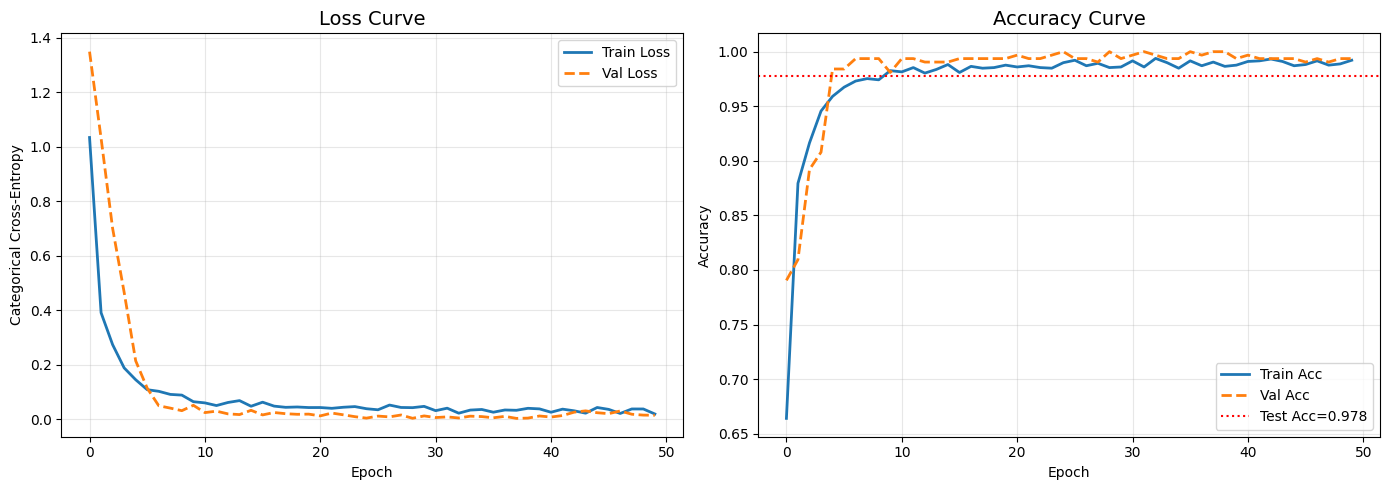

Saved: training_curves.png


In [20]:
# ── Predict on test set ─────────────────────────────────────────────────────
y_pred_prob = best_model.predict(E_test, verbose=0)   # (N, n_classes)
y_pred_int  = np.argmax(y_pred_prob, axis=1)
y_true_int  = y_int_test.copy()

# ── 1. Training Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[0].set_title('Loss Curve', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Cross-Entropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   linewidth=2, linestyle='--')
axes[1].axhline(test_acc, color='red', linestyle=':', linewidth=1.5, label=f'Test Acc={test_acc:.3f}')
axes[1].set_title('Accuracy Curve', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()
print('Saved: training_curves.png')

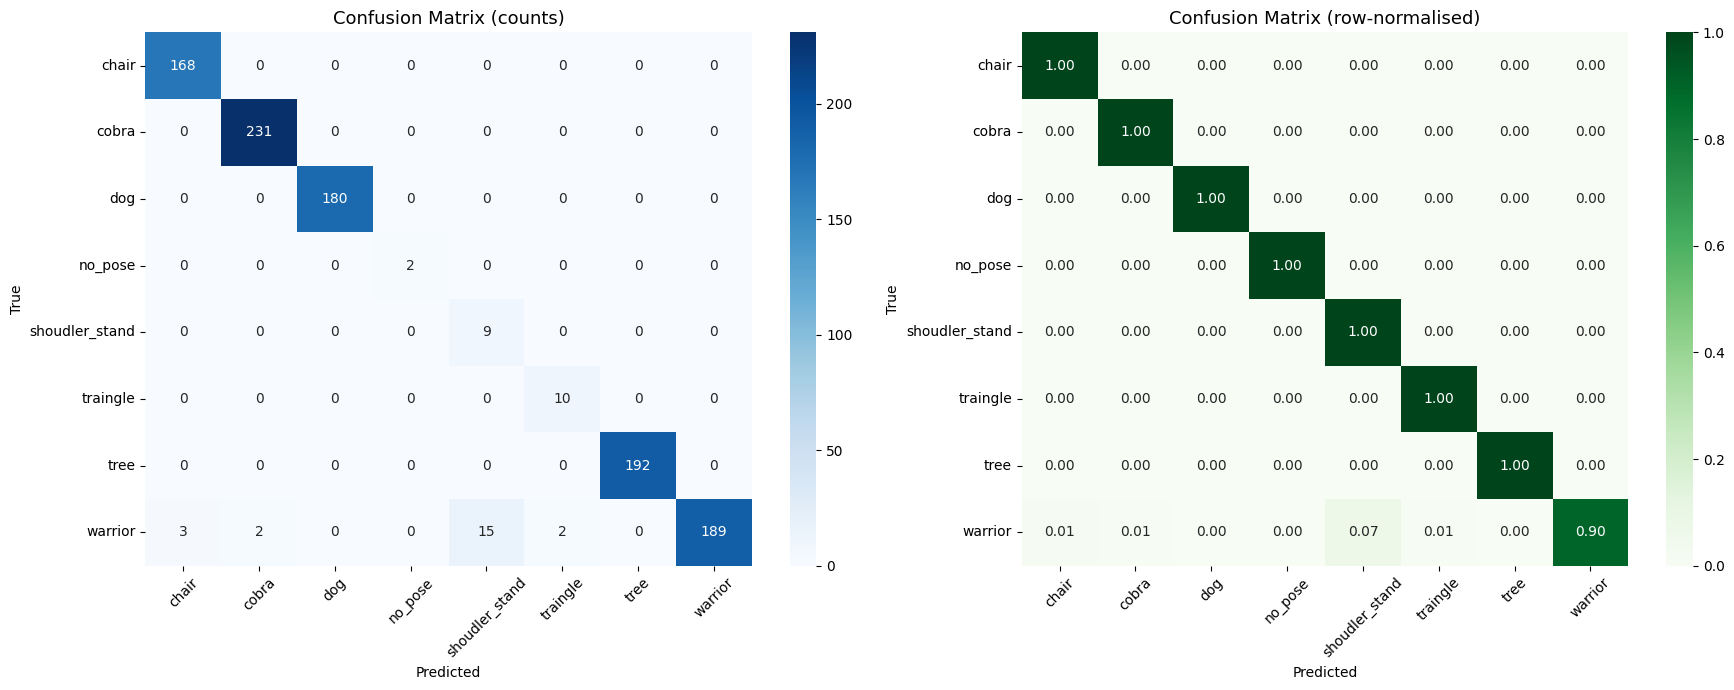

Saved: confusion_matrix.png


In [21]:
# ── 2. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true_int, y_pred_int)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalised)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()
print('Saved: confusion_matrix.png')

In [22]:
# ── 3. Classification Report ─────────────────────────────────────────────────
report = classification_report(
    y_true_int, y_pred_int,
    target_names=CLASS_NAMES,
    digits=4
)
print('=== Classification Report ===')
print(report)

# Save as CSV too
report_dict = classification_report(
    y_true_int, y_pred_int,
    target_names=CLASS_NAMES,
    output_dict=True
)
pd.DataFrame(report_dict).T.to_csv('classification_report.csv')
print('Saved: classification_report.csv')

=== Classification Report ===
                precision    recall  f1-score   support

         chair     0.9825    1.0000    0.9912       168
         cobra     0.9914    1.0000    0.9957       231
           dog     1.0000    1.0000    1.0000       180
       no_pose     1.0000    1.0000    1.0000         2
shoudler_stand     0.3750    1.0000    0.5455         9
      traingle     0.8333    1.0000    0.9091        10
          tree     1.0000    1.0000    1.0000       192
       warrior     1.0000    0.8957    0.9450       211

      accuracy                         0.9781      1003
     macro avg     0.8978    0.9870    0.9233      1003
  weighted avg     0.9878    0.9781    0.9810      1003

Saved: classification_report.csv


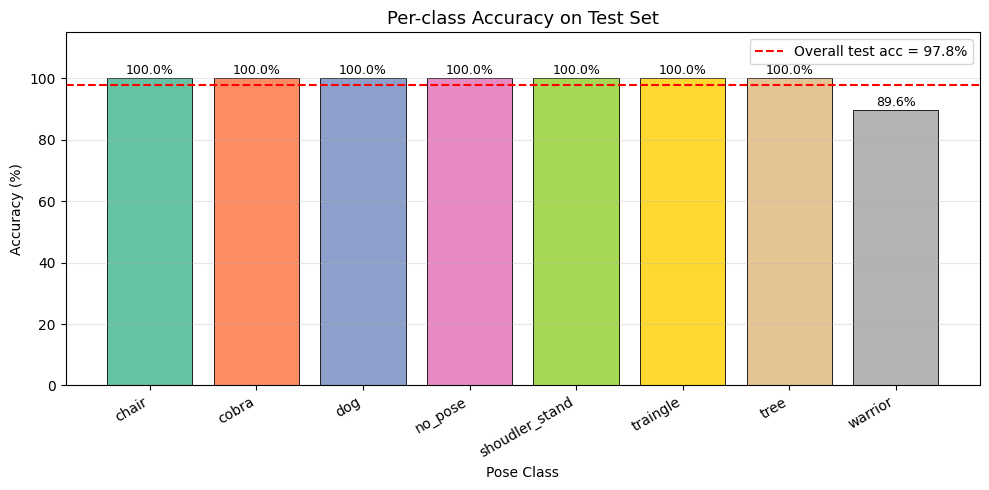

Saved: per_class_accuracy.png


In [23]:
# ── 4. Per-class accuracy bar chart ─────────────────────────────────────────
per_class_acc = cm_norm.diagonal()

plt.figure(figsize=(10, 5))
bars = plt.bar(CLASS_NAMES, per_class_acc * 100,
               color=plt.cm.Set2(np.linspace(0, 1, N_CLASSES)),
               edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.axhline(test_acc * 100, color='red', linestyle='--',
            linewidth=1.5, label=f'Overall test acc = {test_acc*100:.1f}%')
plt.ylim(0, 115)
plt.title('Per-class Accuracy on Test Set', fontsize=13)
plt.xlabel('Pose Class')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=120)
plt.show()
print('Saved: per_class_accuracy.png')

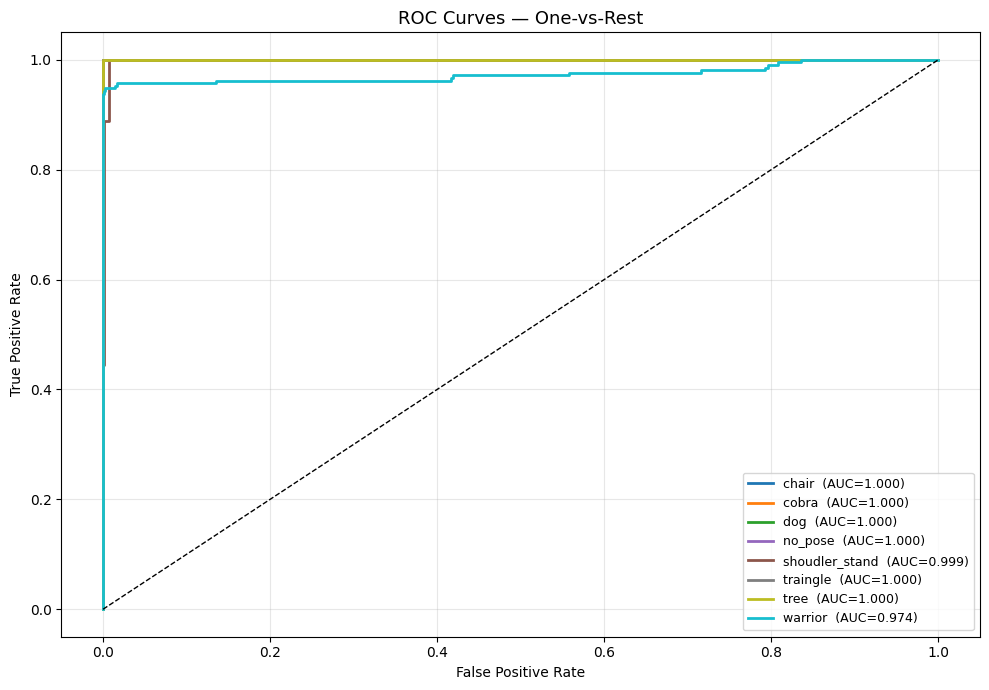

Saved: roc_curves.png
Macro-average AUC : 0.9966


In [24]:
# ── 5. ROC curves (one-vs-rest) ──────────────────────────────────────────────
y_true_bin = label_binarize(y_true_int, classes=list(range(N_CLASSES)))

fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(N_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))
plt.figure(figsize=(10, 7))
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    plt.plot(fpr_dict[i], tpr_dict[i], color=color, linewidth=2,
             label=f'{cls_name}  (AUC={roc_auc_dict[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curves — One-vs-Rest', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120)
plt.show()
print('Saved: roc_curves.png')

# Macro-average AUC
macro_auc = np.mean(list(roc_auc_dict.values()))
print(f'Macro-average AUC : {macro_auc:.4f}')

In [ ]:
# ── 6. Summary table ─────────────────────────────────────────────────────────
print('\n' + '='*55)
print('         FINAL EVALUATION SUMMARY')
print('='*55)
print(f'  Test Loss           : {test_loss:.4f}')
print(f'  Test Accuracy       : {test_acc * 100:.2f}%')
print(f'  Macro-average AUC   : {macro_auc:.4f}')
print(f'  Number of classes   : {N_CLASSES}')
print(f'  Input features      : {FEATURE_DIM} raw → {EMBEDDING_DIM} normalized')
print(f'  Test samples        : {len(y_true_int)}')
print('-'*55)
print('  Per-class AUC:')
for i, name in enumerate(CLASS_NAMES):
    print(f'    {name:<20}: {roc_auc_dict[i]:.4f}')
print('='*55)

## 12. Save model

In [26]:
# Save as .keras (native format)
best_model.save('yoga_pose_classifier.keras')
print('Saved: yoga_pose_classifier.keras')

# Export SavedModel for TFLite/TFServing
best_model.export('yoga_pose_classifier_savedmodel')
print('Saved: yoga_pose_classifier_savedmodel/')

# TFLite conversion
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('yoga_pose_classifier.tflite', 'wb') as f:
    f.write(tflite_model)
print('Saved: yoga_pose_classifier.tflite')

# Save class names
with open('class_names.txt', 'w') as f:
    f.write('\n'.join(CLASS_NAMES))
print('Saved: class_names.txt')
print('Classes:', CLASS_NAMES)

Saved: yoga_pose_classifier.keras
Saved artifact at 'yoga_pose_classifier_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 66), dtype=tf.float32, name='pose_embedding')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  135850010684944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010679952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010684752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010685136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010685904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010685712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010683216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010673808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010680144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135850010679760: TensorSpec(shape=(), dtyp

## 13. Single-image inference demo

In [ ]:
def predict_pose(image_path: str, model, class_names: list) -> dict:
    """
    Runs MediaPipe + classifier on a single image.
    Returns dict with predicted class, confidence, and all class probabilities.
    """
    extractor = PoseLandmarkExtractor()
    landmarks, ok = extractor.extract(image_path)
    extractor.close()

    if not ok:
        return {'error': 'No pose detected in image'}

    embedding = normalize_and_embed(
        tf.cast(landmarks[np.newaxis, :], tf.float32)
    ).numpy()

    probs      = model.predict(embedding, verbose=0)[0]
    top_idx    = int(np.argmax(probs))

    return {
        'predicted_class': class_names[top_idx],
        'confidence':      float(probs[top_idx]),
        'all_probs':       {cls: float(p) for cls, p in zip(class_names, probs)}
    }


# Demo: replace with any image path from the test set
sample_class = CLASS_NAMES[0]
sample_dir   = f'yoga_poses/test/{sample_class}'
sample_image = os.path.join(sample_dir, os.listdir(sample_dir)[0])

result = predict_pose(sample_image, best_model, CLASS_NAMES)
print(f'Image         : {sample_image}')
print(f'True class    : {sample_class}')
print(f'Predicted     : {result.get("predicted_class")}')
print(f'Confidence    : {result.get("confidence", 0):.3f}')
print('All probs:')
for cls, p in sorted(result.get('all_probs', {}).items(), key=lambda x: -x[1]):
    bar = '█' * int(p * 30)
    print(f'  {cls:<20} {p:.4f}  {bar}')

In [27]:
from google.colab import files

download_files = [
    'best_yoga_model.keras',
    'classification_report.csv',
    'confusion_matrix.png',
    'per_class_accuracy.png',
    'roc_curves.png',
    'training_curves.png',
    'train_landmarks.csv',
    'test_landmarks.csv',
    'pose_landmarker_heavy.task'
]

for f in download_files:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloaded: {f}')
    else:
        print(f'Missing: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: best_yoga_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: test_landmarks.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: pose_landmarker_heavy.task
